# Lab 9 — World Models for Physical Systems

**Advanced Deep Learning** — 2025-2026

- **Lecture:** Prof. Ye Zhu
- **Lab:** Dr Guillaume Lachaud

---

One system. Three paradigms. One question: *what makes a trustworthy world model?*

| Model | Physics role | Conservation |
|-------|-------------|-------------|
| **MLP** | None — pure data | Not enforced |
| **HNN** | Structural inductive bias | Enforced by architecture |
| **PINN** | Regularization via ODE residual | Approximate, via loss |

You will probe each model on a simple pendulum, observe where they succeed and fail, and discover that **conservation must be enforced structurally or it will be violated**.

In [1]:
import torch
import numpy as np
import os
from IPython.display import HTML, display

from src.physics_lab.utils import get_device, set_seed
from src.physics_lab.physics import (
    pendulum_hamiltonian,
    pendulum_dynamics,
    generate_trajectory,
    generate_training_data,
    generate_pinn_training_data,
    train_pinn,
)
from src.physics_lab.models import (
    BaselineMLP,
    HamiltonianNN,
    PINN,
    euler_step,
    symplectic_step,
    rollout,
    load_model,
    count_parameters,
)
from src.physics_lab.visualization import (
    animate_pendulum,
    plot_phase_portrait,
    plot_energy_drift,
    plot_trajectory_comparison,
    plot_training_data_comparison,
    plot_comparison,
    plot_pinn_loss_curves,
)

set_seed(42)
device = get_device()
print(f"Device: {device} | PyTorch: {torch.__version__}")

Device: cuda | PyTorch: 2.5.1


---
# Part 0: Physics & Architecture Recap

> See also the **Hamiltonian Primer** document for a fuller derivation.

## Hamiltonian Mechanics — Key Ideas

For a system with generalized coordinate $q$ and conjugate momentum $p$, the **Hamiltonian** $H(q, p) = T + V$ is the total energy. The equations of motion are:

$$\dot{q} = \frac{\partial H}{\partial p}, \qquad \dot{p} = -\frac{\partial H}{\partial q}$$

**Key property:** Along any trajectory, $\frac{dH}{dt} = \frac{\partial H}{\partial q}\dot{q} + \frac{\partial H}{\partial p}\dot{p} = 0$. Energy is conserved.

## The Simple Pendulum

For a pendulum of mass $m$, length $L$, under gravity $g$:

$$H(\theta, p_\theta) = \frac{p_\theta^2}{2mL^2} - mgL\cos\theta$$

where $\theta$ is the angle and $p_\theta = mL^2\dot\theta$ is the angular momentum.

In [2]:
t, states = generate_trajectory(q0=1.0, p0=0.0, t_span=(0, 10), n_points=1000)
q, p = states[:, 0], states[:, 1]
H = pendulum_hamiltonian(q, p)
H_drift = np.max(H) - np.min(H)

if H_drift < 1e-6:
    print(f"SUCCESS: Energy conservation verified! Max drift: {H_drift:.2e}")
else:
    print(f"WARNING: Energy drift = {H_drift:.2e} (expected < 1e-6)")

SUCCESS: Energy conservation verified! Max drift: 4.98e-09


## Three Paradigms, One System

All three models learn pendulum dynamics, but encode physics differently:

**MLP** (Baseline)
- Input: $(\theta, p_\theta)$ → Output: $(\dot\theta, \dot{p}_\theta)$
- Trained on dense trajectory data — no physics knowledge
- Integration: standard Euler

**HNN** (Hamiltonian Neural Network)
- Learns a scalar $\hat{H}(\theta, p_\theta)$
- Derives $\dot\theta = \partial\hat{H}/\partial p$, $\dot{p} = -\partial\hat{H}/\partial\theta$ via `autograd`
- Conservation is **structural** — enforced by architecture

**PINN** (Physics-Informed Neural Network)
- Input: $t$ → Output: $\theta(t)$ directly
- Trained on sparse observations + ODE residual penalty
- Physics is **approximate** — enforced as a loss term

---
**Your Prediction:** Before running any experiment, rank the three models (MLP, HNN, PINN) for long-horizon extrapolation accuracy. Justify your ranking.

1. Hamiltonian Neural Network, HNN provides the highest long-horizon extrapolation accuracy. By parameterizing the scalar energy $\hat{H}$ and enforcing the equations of motion via automatic differentiation, the network guarantees a divergence-free vector field in phase space:$$\nabla \cdot \begin{pmatrix} \dot{\theta} \\ \dot{p}_\theta \end{pmatrix} = \frac{\partial^2 \hat{H}}{\partial \theta \partial p_\theta} - \frac{\partial^2 \hat{H}}{\partial p_\theta \partial \theta} = 0$$This structural bias restricts predicted trajectories strictly to the level sets of $\hat{H}$. Even when extrapolating to unseen times or initial conditions, the underlying geometry of the phase space is preserved, preventing systemic energy dissipation or explosion.

2. Physics-Informed Neural Network, PINN relies on soft constraints, making its extrapolation accuracy severely limited. The dynamics are enforced via a residual penalty in the loss function:$$\mathcal{L}_{physics} = \left\| \frac{d^2\theta}{dt^2} + \frac{g}{L} \sin(\theta) \right\|^2$$While effective for interpolation within the temporal training interval, standard feedforward networks suffer from spectral bias. They inherently struggle to extrapolate continuous, oscillatory functions outside their training domain $t$, leading to rapid damping or divergence once the boundary is crossed.

3. Multilayer Perceptron, The baseline MLP lacks any geometric or physical priors and exhibits the most rapid accumulation of error. It approximates the local vector field purely from data. When integrated autoregressively using a standard explicit method like Forward Euler, it accumulates unconstrained truncation errors at each step:$$\begin{pmatrix} \theta_{k+1} \\ p_{k+1} \end{pmatrix} = \begin{pmatrix} \theta_k \\ p_k \end{pmatrix} + \Delta t \cdot f_{\text{MLP}}(\theta_k, p_k)$$Without an invariant manifold to anchor the dynamics, these errors compound exponentially, systematically pushing the state off the true energy contour and violating the physical constraints of the pendulum.

---
# Part 1 — Probing the Three Models

## Sub-part A: MLP Baseline (~20 min)

The MLP learns a direct mapping $(\theta, p_\theta) \to (\dot\theta, \dot{p}_\theta)$ from dense trajectory data. It has **no physics knowledge** — just function approximation.

In [3]:
ckpt = "checkpoints/mlp.safetensors"
config_path = "checkpoints/training_config.pt"

if not os.path.exists(ckpt) or not os.path.exists(config_path):
    raise FileNotFoundError("Checkpoints not found in checkpoints/. Ask your instructor.")

config = torch.load(config_path, weights_only=False)
mlp = load_model(ckpt, BaselineMLP, device=device,
                 hidden_dim=config["hidden_dim"], n_layers=config["n_layers"])

print(f"MLP Parameters: {count_parameters(mlp):,}")
print(f"Architecture: {config['n_layers']}-layer MLP, hidden_dim={config['hidden_dim']}")

MLP Parameters: 8,642
Architecture: 3-layer MLP, hidden_dim=64


C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\2093840121.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_traj.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\2093840121.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_phase.show()


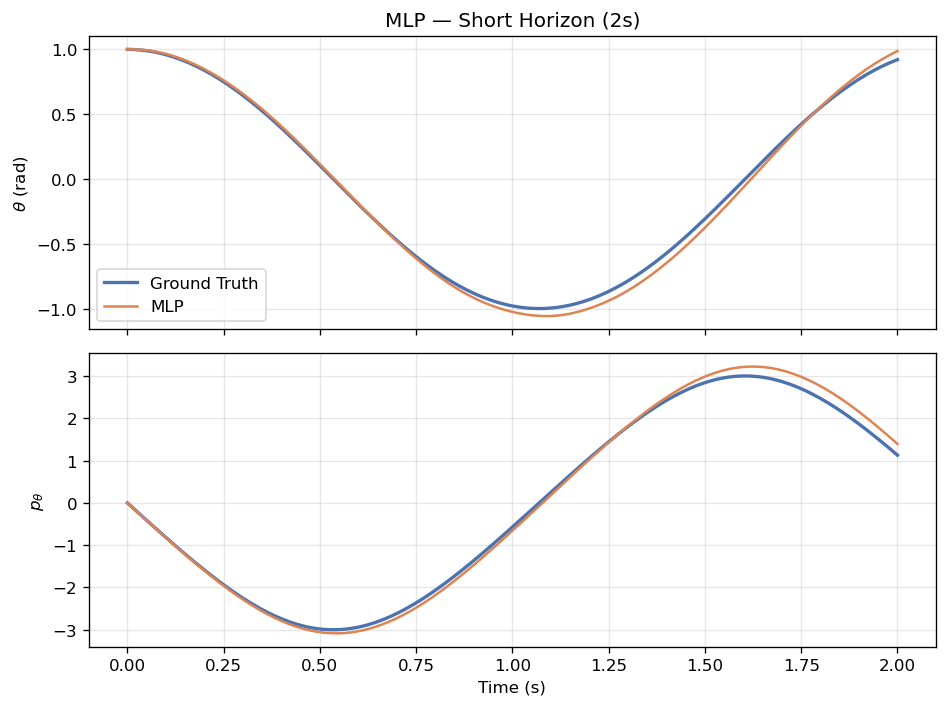

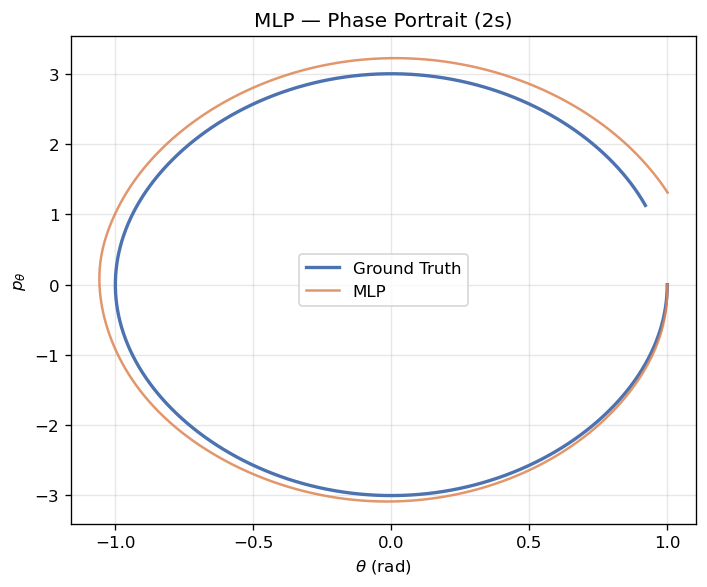

In [4]:
t_short, gt_short = generate_trajectory(
    q0=config["q0"], p0=config["p0"], t_span=(0, 2), n_points=200,
    m=config["m"], L=config["L"], g=config["g"],
)

init = torch.tensor([config["q0"], config["p0"]], dtype=torch.float32)
mlp_short = rollout(mlp, init, dt=0.01, n_steps=200, step_fn=euler_step)

fig_traj = plot_trajectory_comparison(
    [gt_short, mlp_short], t_short, ["Ground Truth", "MLP"], title="MLP — Short Horizon (2s)"
)
fig_phase = plot_phase_portrait(
    [gt_short, mlp_short], ["Ground Truth", "MLP"], title="MLP — Phase Portrait (2s)"
)

fig_traj.show()
fig_phase.show()

C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\1251551510.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_traj_long.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\1251551510.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_phase_long.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\1251551510.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_energy.show()


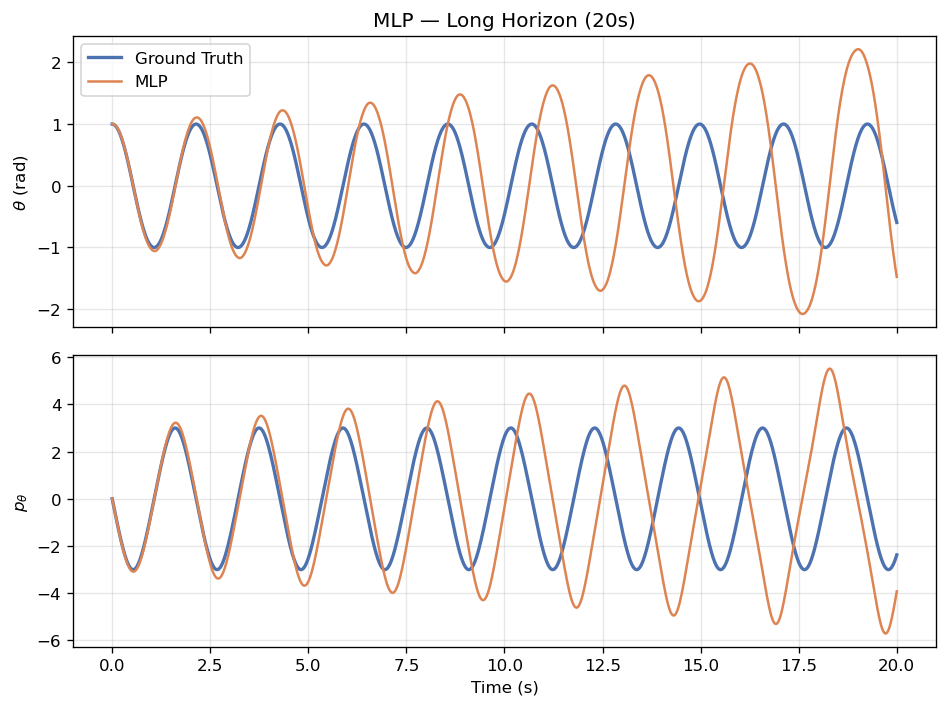

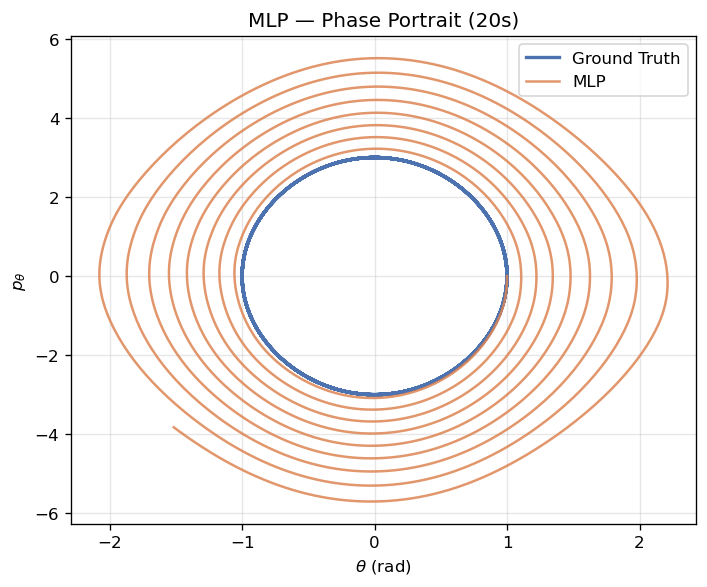

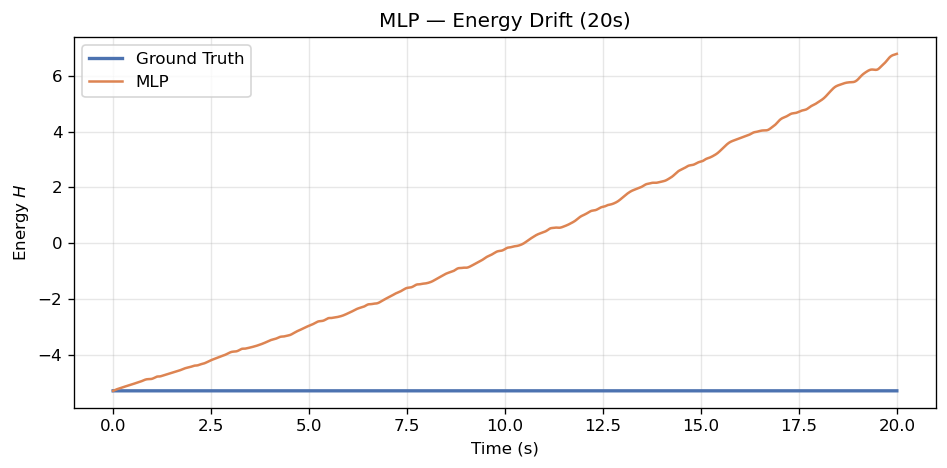

In [5]:
t_long, gt_long = generate_trajectory(
    q0=config["q0"], p0=config["p0"], t_span=(0, 20), n_points=2000,
    m=config["m"], L=config["L"], g=config["g"],
)

mlp_long = rollout(mlp, init, dt=0.01, n_steps=2000, step_fn=euler_step)

fig_traj_long = plot_trajectory_comparison(
    [gt_long, mlp_long], t_long, ["Ground Truth", "MLP"], title="MLP — Long Horizon (20s)"
)
fig_phase_long = plot_phase_portrait(
    [gt_long, mlp_long], ["Ground Truth", "MLP"], title="MLP — Phase Portrait (20s)"
)

H_fn = lambda q, p: pendulum_hamiltonian(q, p, m=config["m"], L=config["L"], g=config["g"])
fig_energy = plot_energy_drift(
    [gt_long, mlp_long], t_long, H_fn, ["Ground Truth", "MLP"], title="MLP — Energy Drift (20s)"
)

fig_traj_long.show()
fig_phase_long.show()
fig_energy.show()

In [ ]:
t_anim, gt_anim = generate_trajectory(
    q0=config["q0"], p0=config["p0"], t_span=(0, 10), n_points=1000,
    m=config["m"], L=config["L"], g=config["g"],
)
mlp_traj_anim = rollout(mlp, init, dt=0.01, n_steps=1000, step_fn=euler_step)

anim_mlp = animate_pendulum(
    [gt_anim, mlp_traj_anim], t_anim, ["Ground Truth", "MLP"],
    L=config["L"], fps=30, speedup=1.0, title="MLP vs Ground Truth (10s)"
)

display(HTML(anim_mlp.to_html5_video()))

### Questions — MLP
**A1:** Look at the energy plot. What physical law is being violated?

Energy is increasing !! Conservation law is not respected

**A2:** At what point in time does the MLP start failing noticeably? Is this a model capacity problem or a structural problem?

Around 5sec the shift is becoming too big. This is a structural problem because nothing can enforce an energy conservation and just a little drift will push a bigger with time.

**A3:** Could you fix this by training on more data or using a bigger MLP? Why or why not?

It will maybe fix for short time but the problem will come later.



---
## Sub-part B: Hamiltonian Neural Network (~25 min)

Instead of learning dynamics directly, the HNN learns a **scalar Hamiltonian** $\hat{H}(q, p)$ and derives dynamics via automatic differentiation. This structurally enforces $dH/dt = 0$ — conservation is not learned, it is **guaranteed by the architecture**.

In [7]:
ckpt_hnn = "checkpoints/hnn.safetensors"
if not os.path.exists(ckpt_hnn):
    raise FileNotFoundError("HNN checkpoint not found. Ask your instructor.")

hnn = load_model(ckpt_hnn, HamiltonianNN, device=device,
                 hidden_dim=config["hidden_dim"], n_layers=config["n_layers"])

print(f"HNN Parameters: {count_parameters(hnn):,}")

HNN Parameters: 8,577


### HNN Forward Pass — Read and Annotate

```python
def forward(self, x):
    # x has shape (batch, 2) with columns [q, p]
    H = self.network(x)          # (1) Learn scalar Hamiltonian
    dH = torch.autograd.grad(H.sum(), x, create_graph=True)[0] # (2) Derive dynamics
    dq_dt =  dH[:, 1:2]          # ∂H/∂p
    dp_dt = -dH[:, 0:1]          # -∂H/∂q
    return torch.cat([dq_dt, dp_dt], dim=1)
```
**Réflexions:** Pourquoi autograd plutôt qu'un second réseau ? Pourquoi `dp_dt` est négatif ?

In [8]:
sym_traj = rollout(hnn, init, dt=0.01, n_steps=10, step_fn=symplectic_step)
eul_traj = rollout(hnn, init, dt=0.01, n_steps=10, step_fn=euler_step)
diff = (sym_traj - eul_traj).abs().max().item()

if diff > 1e-6:
    print("SUCCESS: Symplectic step test passed! (Differs from Euler)")
else:
    print("WARNING: Symplectic step not implemented yet. Using fallback.")

SUCCESS: Symplectic step test passed! (Differs from Euler)


c:\Users\Alexander\anaconda3\envs\adl_env\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\761714529.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_traj_hnn.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\761714529.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_phase_hnn.show()


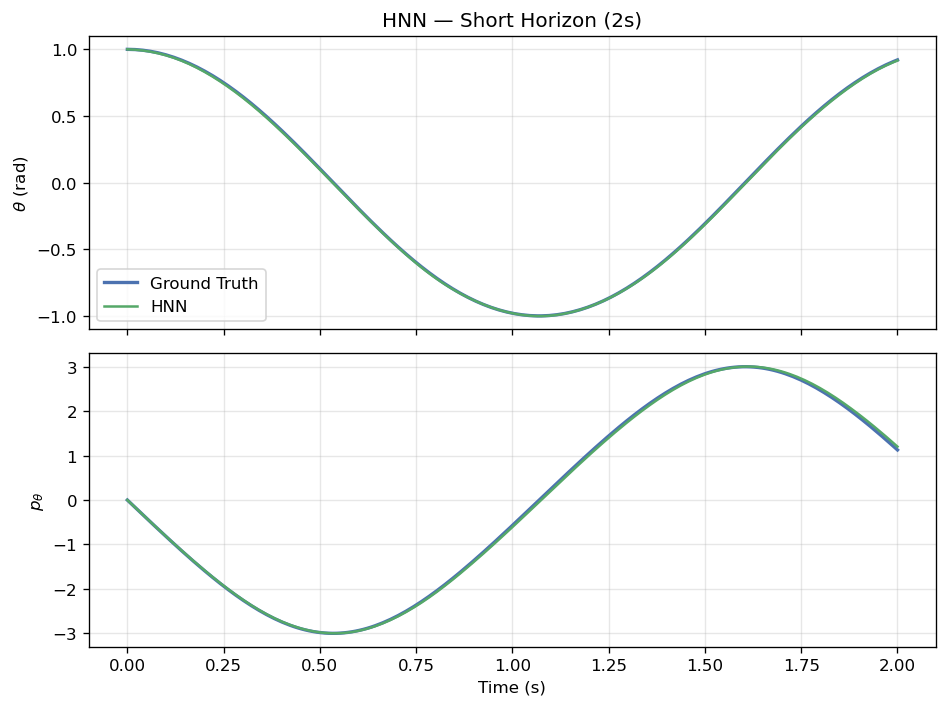

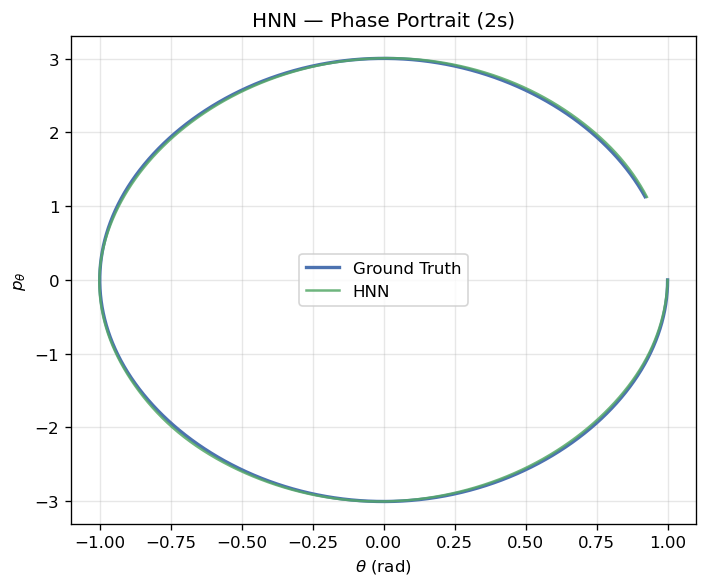

In [9]:
hnn_short = rollout(hnn, init, dt=0.01, n_steps=200, step_fn=symplectic_step)

fig_traj_hnn = plot_trajectory_comparison(
    [gt_short, hnn_short], t_short, ["Ground Truth", "HNN"], title="HNN — Short Horizon (2s)"
)
fig_phase_hnn = plot_phase_portrait(
    [gt_short, hnn_short], ["Ground Truth", "HNN"], title="HNN — Phase Portrait (2s)"
)

fig_traj_hnn.show()
fig_phase_hnn.show()

C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\1189708574.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_traj_hnn_long.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\1189708574.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_energy_hnn.show()


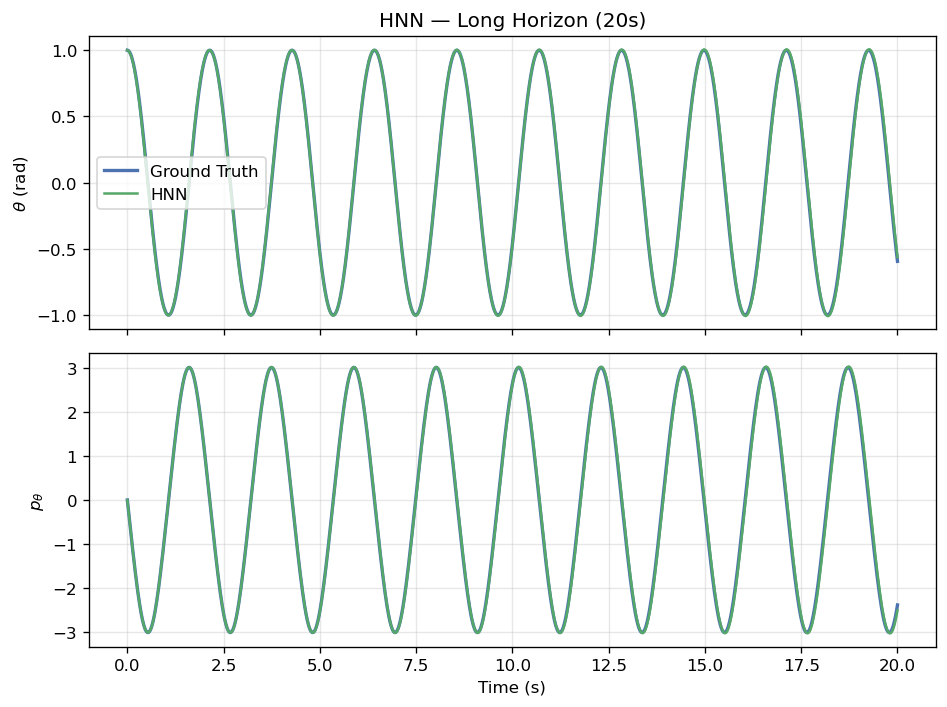

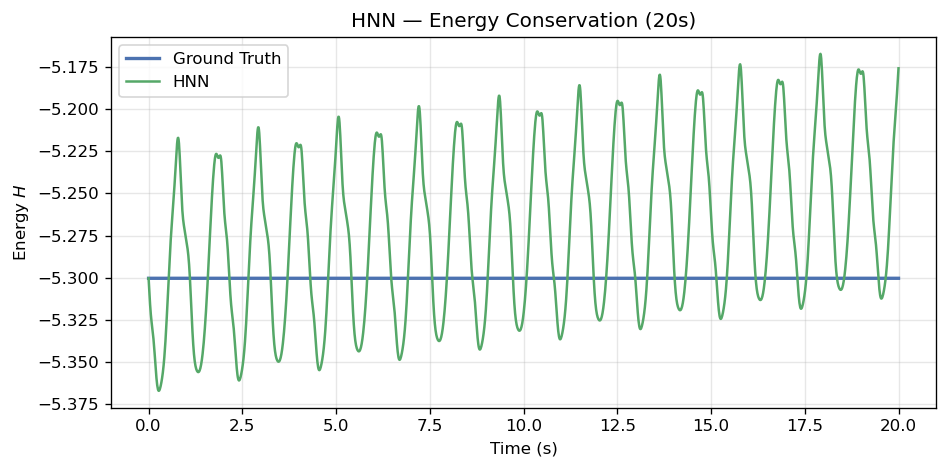

In [10]:
hnn_long = rollout(hnn, init, dt=0.01, n_steps=2000, step_fn=symplectic_step)

fig_traj_hnn_long = plot_trajectory_comparison(
    [gt_long, hnn_long], t_long, ["Ground Truth", "HNN"], title="HNN — Long Horizon (20s)"
)
fig_energy_hnn = plot_energy_drift(
    [gt_long, hnn_long], t_long, H_fn, ["Ground Truth", "HNN"], title="HNN — Energy Conservation (20s)"
)

fig_traj_hnn_long.show()
fig_energy_hnn.show()

In [ ]:
hnn_traj_anim = rollout(hnn, init, dt=0.01, n_steps=1000, step_fn=symplectic_step)
anim_hnn = animate_pendulum(
    [gt_anim, hnn_traj_anim], t_anim, ["Ground Truth", "HNN"],
    L=config["L"], fps=30, speedup=1.0, title="HNN vs Ground Truth (10s)"
)
display(HTML(anim_hnn.to_html5_video()))

### Questions — HNN
**B1:** Compare the phase portrait to the MLP. What changed? The HNN and MLP were trained on identical data — what's different?

HNN tries to keep around the good energy value.

**B2:** The HNN conserves energy by construction. Does this mean it predicts the correct trajectory? Can you think of a case where conservation holds but the trajectory is wrong?

No. Conserving energy guarantees that the system state remains strictly on a level set of the learned Hamiltonian, $\hat{H}$. It does not guarantee that $\hat{H}$ matches the true physical Hamiltonian, $H$, nor does it ensure the correct temporal evolution along the phase space orbit.

---
## Sub-part C: Physics-Informed Neural Network (~25 min)

The PINN learns $\theta(t)$ directly from sparse observations, regularized by the pendulum ODE:

$$\mathcal{L} = \underbrace{\mathcal{L}_\text{data}}_{\text{sparse observations}} + \lambda \underbrace{\mathcal{L}_\text{physics}}_{\ddot\theta + \frac{g}{L}\sin\theta = 0}$$

Unlike MLP/HNN, the PINN doesn't need dense trajectory data — just a few scattered $(t, \theta)$ points plus the governing equation.

In [11]:
ckpt_pinn = "checkpoints/pinn.safetensors"
if not os.path.exists(ckpt_pinn):
    raise FileNotFoundError("PINN checkpoint not found.")

pinn = load_model(ckpt_pinn, PINN, device=device, hidden_dim=config["hidden_dim"], n_layers=4)
print(f"PINN Parameters: {count_parameters(pinn):,}")

PINN Parameters: 12,673


C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\1692801210.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_data.show()


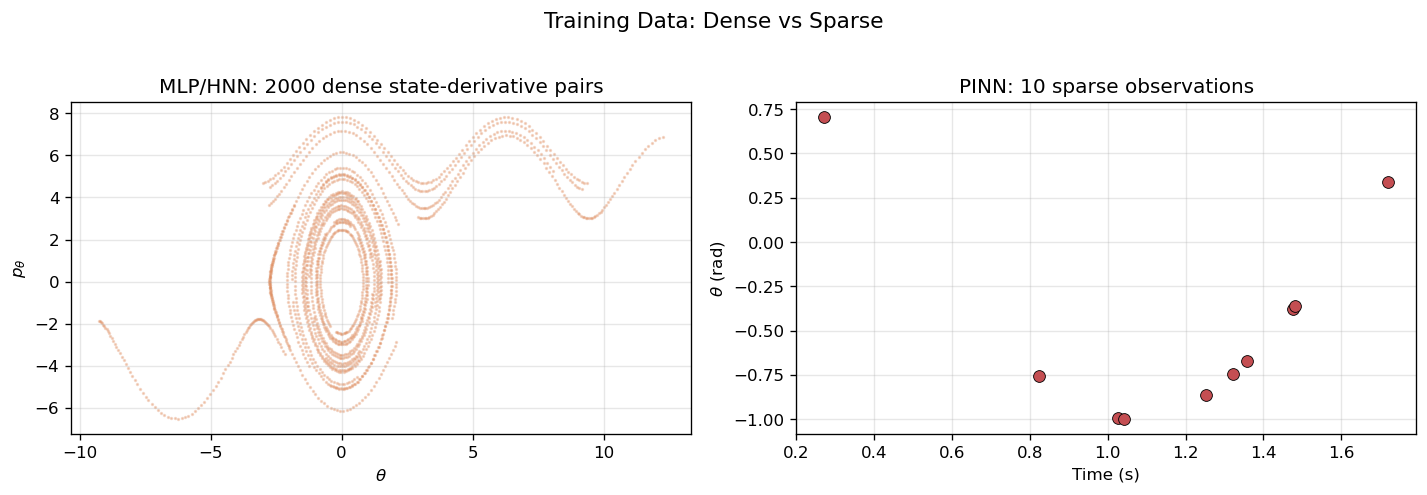

In [12]:
states_dense, derivs = generate_training_data(
    n_trajectories=20, n_points_per=100, m=config["m"], L=config["L"], g=config["g"]
)
t_obs, theta_obs, t_colloc = generate_pinn_training_data(
    n_obs=10, n_colloc=500, q0=config["q0"], p0=config["p0"], m=config["m"], L=config["L"], g=config["g"]
)

fig_data = plot_training_data_comparison(states_dense, t_obs, theta_obs)
fig_data.show()

C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\3135466976.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_traj_pinn_short.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\3135466976.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_traj_pinn_long.show()
C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\3135466976.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_energy_pinn.show()


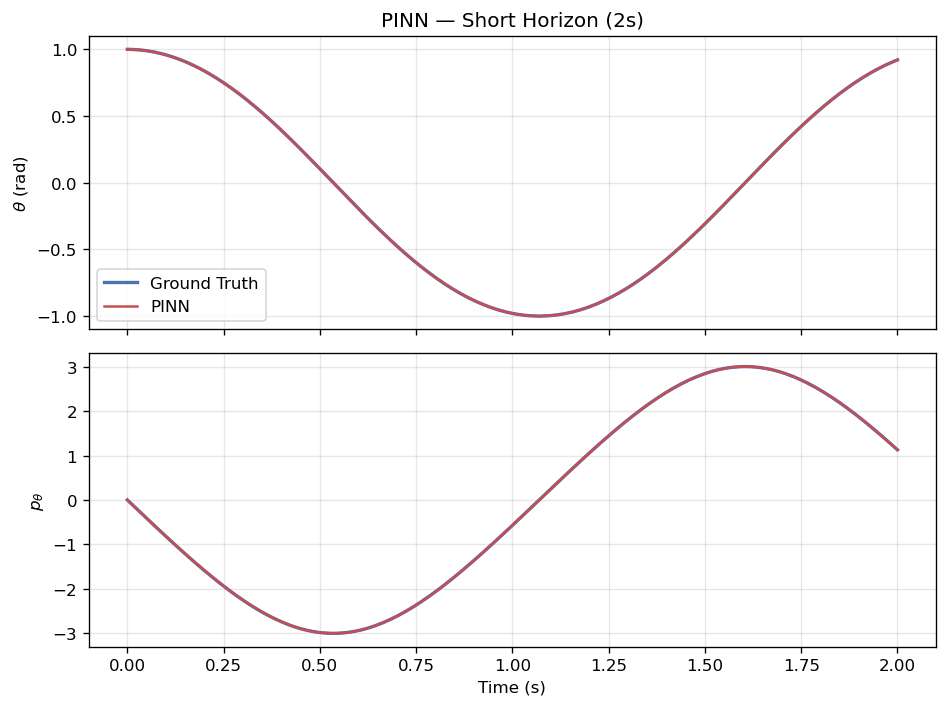

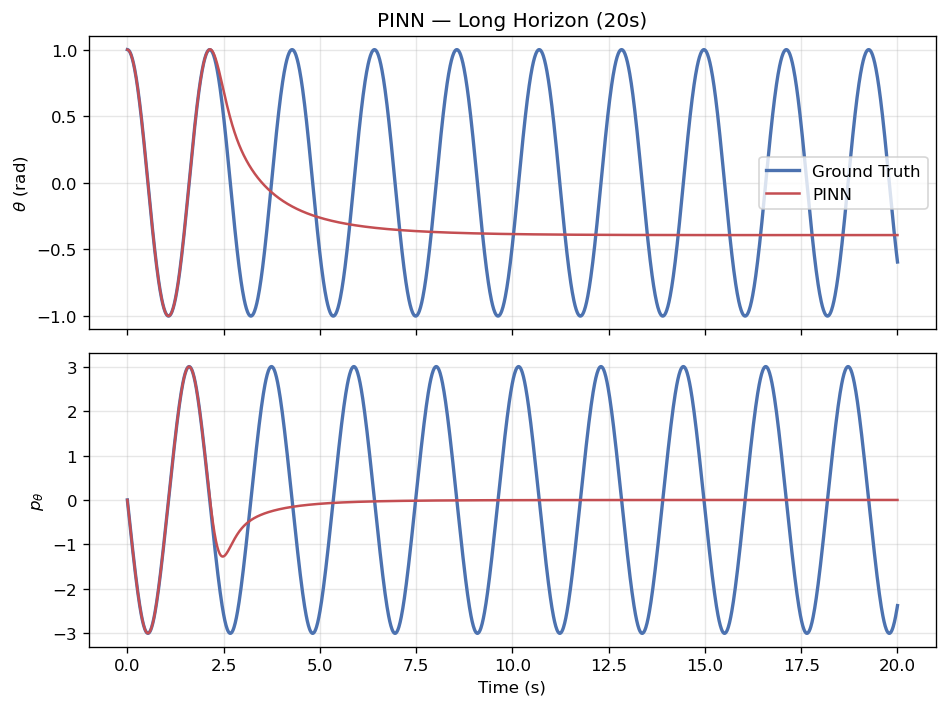

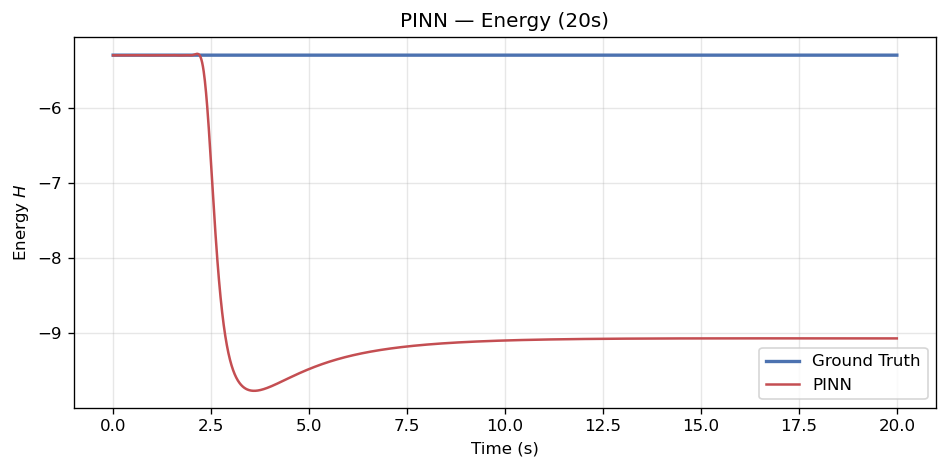

In [13]:
def pinn_trajectory(t_array, pinn_model, m, L):
    dev = next(pinn_model.parameters()).device
    t_tensor = torch.tensor(t_array, dtype=torch.float32, device=dev).unsqueeze(1).requires_grad_(True)
    theta = pinn_model(t_tensor)
    dtheta_dt = torch.autograd.grad(theta, t_tensor, grad_outputs=torch.ones_like(theta), create_graph=False)[0]
    p = m * L ** 2 * dtheta_dt
    return torch.cat([theta, p], dim=1).detach().cpu()

pinn_short = pinn_trajectory(t_short, pinn, config["m"], config["L"])
pinn_long = pinn_trajectory(t_long, pinn, config["m"], config["L"])

fig_traj_pinn_short = plot_trajectory_comparison(
    [gt_short, pinn_short], t_short, ["Ground Truth", "PINN"], title="PINN — Short Horizon (2s)"
)
fig_traj_pinn_long = plot_trajectory_comparison(
    [gt_long, pinn_long], t_long, ["Ground Truth", "PINN"], title="PINN — Long Horizon (20s)"
)
fig_energy_pinn = plot_energy_drift(
    [gt_long, pinn_long], t_long, H_fn, ["Ground Truth", "PINN"], title="PINN — Energy (20s)"
)

fig_traj_pinn_short.show()
fig_traj_pinn_long.show()
fig_energy_pinn.show()

In [ ]:
pinn_traj_anim = pinn_trajectory(t_anim, pinn, config["m"], config["L"])
anim_pinn = animate_pendulum(
    [gt_anim, pinn_traj_anim], t_anim, ["Ground Truth", "PINN"],
    L=config["L"], fps=30, speedup=1.0, title="PINN vs Ground Truth (10s)"
)
display(HTML(anim_pinn.to_html5_video()))

### Questions — PINN
**C1:** The PINN never saw a full trajectory. What did it use instead of data to reconstruct the dynamics?
**C2:** Compare PINN and MLP accuracy on the short horizon with only 10 training points. Which wins? Why?
**C3:** Does the PINN conserve energy? Is this structural like the HNN, or something else?

In [14]:
# Modification statique pour expérimenter le réentraînement du PINN
retrain_pinn = False
lambda_val = 0.0 # équivalent à log10(lambda), soit lambda = 1.0

if retrain_pinn:
    lam = 10 ** lambda_val
    pinn_new = PINN(hidden_dim=config["hidden_dim"], n_layers=4)
    history = train_pinn(
        pinn_new, t_obs, theta_obs, t_colloc,
        n_epochs=2000, lr=1e-3, lambda_physics=lam,
        m=config["m"], L=config["L"], g=config["g"],
        device=str(device), verbose=False,
    )
    fig_loss = plot_pinn_loss_curves(history, title=f"PINN Training (\u03bb = {lam:.2f})")
    fig_loss.show()

---
# Part 2: Synthesis — All Three Side by Side

C:\Users\Alexander\AppData\Local\Temp\ipykernel_36464\3698903695.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_comparison.show()


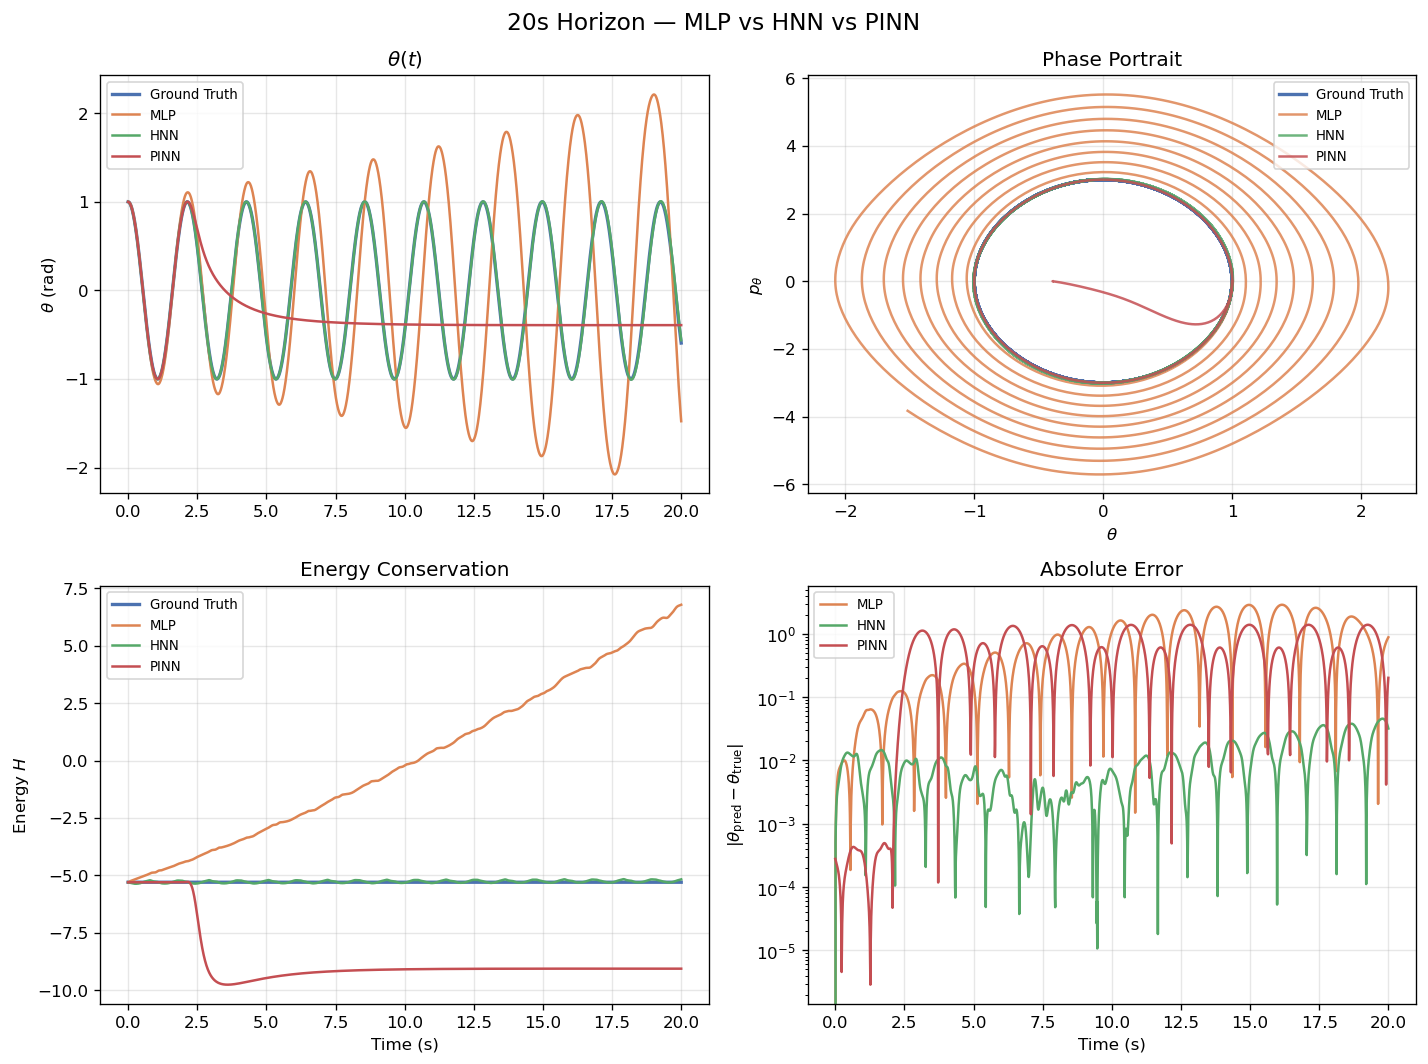

In [15]:
fig_comparison = plot_comparison(
    {"MLP": mlp_long, "HNN": hnn_long, "PINN": pinn_long},
    gt_long, t_long, H_fn, title="20s Horizon — MLP vs HNN vs PINN"
)
fig_comparison.show()

In [ ]:
anim_all = animate_pendulum(
    [gt_anim, mlp_traj_anim, hnn_traj_anim, pinn_traj_anim], t_anim,
    ["Ground Truth", "MLP", "HNN", "PINN"],
    L=config["L"], fps=30, speedup=1.0, title="Ground Truth vs MLP vs HNN vs PINN (10s)"
)
display(HTML(anim_all.to_html5_video()))

### Synthesis Questions
**S1:** Revisit your prediction from Part 0. Were you right? What surprised you?

  1. HNN > 2. MLP > 3. PINN

  PINN collpase is surprising.


**S2:** Rank the three models as world models for a robot controller that must run for 60 seconds. Justify your ranking.


**S3:** HNN enforces physics structurally. PINN enforces it as a loss. What are the trade-offs of each approach? When would you choose one over the other?

HNN better for conservative model and PINN for complex physics.


**S4:** If you had abundant data but needed long-horizon predictions, which would you choose? What if data was scarce?

Scarce => PINN

Long horizon => HNN

---
# Part 3: Extension — Double Pendulum (Optional)

> This section is a stub for a future extension.

The double pendulum is a **chaotic** system: tiny perturbations in initial conditions grow exponentially. This means:

- Even the HNN, which conserves energy perfectly, will **diverge from the true trajectory** after a short time
- Energy conservation is **necessary but not sufficient** for accurate long-horizon prediction in chaotic regimes

**Questions to think about:**

- If conservation holds but trajectories diverge, what metric should we use to evaluate a world model on chaotic systems?
- What additional inductive biases might help? (Symplectic structure? Lyapunov exponent awareness? Ensemble methods?)

This is an open research question — there is no single right answer.